In [1]:
import os
from typing import Dict, Sequence, Optional

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl


import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from pcmdi_enso_reader import (
    ENSODiagReader
)

In [2]:
class ENSOPatternMapPlotter:
    """
    Plot ENSO diagnostics as Hovmöller diagrams (y_dim vs longitude) for:
      - reference (obs)
      - hist ensemble mean
      - future ensemble mean

    Expects a data_dict with keys like:
      data_dict["reference"] : (y_dim, lon)
      data_dict["hist"]      : (member, y_dim, lon)
      data_dict["future"]    : (member, y_dim, lon)

    For the ENSO seasonality metric, y_dim = 'months', lon = 'longitude'.
    """

    def __init__(
        self,
        data_dict: Dict[str, xr.DataArray],
        fig_dir: str,
        plot_dict: Dict[str, dict],
        group_order: Sequence[str] = ("hist", "future"),
        obs_key: str = "reference",
        lat_name: str = "latitude",      # here: vertical axis (e.g., 'months')
        lon_name: str = "longitude_a",   # here: horizontal axis (e.g., 'longitude')
    ):
        """
        Parameters
        ----------
        data_dict : dict
            Mapping from group key to DataArray.
            Must contain obs_key and all groups in group_order.
        fig_dir : str
            Directory where figures are saved.
        plot_dict : dict
            Styling information keyed by group name, e.g.
              {
                "reference": {"label": "ERA-Interim (Ref)"},
                "hist":      {"label": "E3SM (Historical)"},
                "future":    {"label": "E3SM (Near-Future)"},
              }
        group_order : sequence
            Model groups to plot after the reference.
        obs_key : str
            Key in data_dict for the observational reference.
        lat_name, lon_name : str
            Names of vertical and horizontal coordinates in the DataArrays.
            For Hovmöller ENSO seasonality: lat_name='months', lon_name='longitude'.
        """
        self.data_dict   = data_dict
        self.fig_dir     = fig_dir
        self.plot_dict   = plot_dict
        self.group_order = tuple(group_order)
        self.obs_key     = obs_key
        self.lat_name    = lat_name
        self.lon_name    = lon_name

        # Build mean & spread fields
        self.mean_maps   = self._build_mean_maps()
        self.spread_maps = self._build_spread_maps()

    # -------------------------------------------------------------------------
    # Internal helpers for mean / spread
    # -------------------------------------------------------------------------
    def _build_mean_maps(self) -> Dict[str, xr.DataArray]:
        """Return dict of mean fields (lat_name, lon_name) for each key."""
        mean_maps = {}

        # ---- reference ----
        if self.obs_key not in self.data_dict:
            raise ValueError(f"data_dict must contain obs_key='{self.obs_key}'")

        ref = self.data_dict[self.obs_key]
        # average any extra dims beyond (lat_name, lon_name)
        extra_dims = [d for d in ref.dims if d not in (self.lat_name, self.lon_name)]
        if extra_dims:
            ref = ref.mean(dim=extra_dims)
        mean_maps[self.obs_key] = ref

        # ---- model groups ----
        for key in self.group_order:
            if key not in self.data_dict:
                raise ValueError(
                    f"Expected group '{key}' in data_dict, "
                    f"found keys: {list(self.data_dict.keys())}"
                )
            da = self.data_dict[key]
            # average over member/sample and any extra dims beyond (lat_name, lon_name)
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if extra_dims:
                da = da.mean(dim=extra_dims)
            mean_maps[key] = da

        return mean_maps

    def _build_spread_maps(self) -> Dict[str, xr.DataArray]:
        """
        Return dict of ensemble spread (std) fields (lat_name, lon_name) for each
        model group. Reference/obs is omitted because it has no ensemble.
        """
        spread_maps = {}
        for key in self.group_order:
            if key not in self.data_dict:
                continue
            da = self.data_dict[key]

            # Treat any non-(lat_name, lon_name) dims as ensemble/sample dims
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if not extra_dims:
                # No ensemble dimension -> no spread
                continue

            spread_maps[key] = da.std(dim=extra_dims)
        return spread_maps

    def _get_panel_label(self, key: str) -> str:
        """Get human-readable label for each panel from plot_dict or the key."""
        style = self.plot_dict.get(key, {})
        return style.get("label", key)
        
    def _format_lon_deg(self, lon):
        """
        Convert numeric longitude to a pretty label, e.g.:
           200 → 200°E or -160° → 160°W.
        """
        # Normalize: convert 0–360 → -180–180
        lon180 = ((lon + 180) % 360) - 180
    
        if lon180 == 0:
            return "0°"
        elif lon180 > 0:
            return f"{abs(lon180):g}°E"
        else:
            return f"{abs(lon180):g}°W"

    # -------------------------------------------------------------------------
    # Single-row Hovmöller plot (3 panels: obs, hist, future)
    # -------------------------------------------------------------------------
    def plot_sst_map(
        self,
        filename: str = "enso_hov_hist_future.pdf",
        cmap: str = "RdBu_r",
        mlevels: Optional[list] = None,
        var_labels: Optional[list] = None,
        title_prefix: str = "",
        figsize: tuple = (14, 3.5),
        fontz: int = 12,
        overlay_spread: bool = False,
        spread_quantile: float = 0.75,
        spread_level: float = None,
        fig_idx: int = 0,
        fig_format: str = "png",
        fig_dpi: int = 300,
        roll_idx: int = 0, 
        n_xtick: int = 5, 
        n_ytick: int = 5, 
        cb_label="SSTA standard deviation (°C)",
    ):
        """
        Plot 3-panel Hovmöller comparison (obs, hist, future) with optional
        ensemble-spread overlay.

        x-axis: self.lon_name (e.g., longitude)
        y-axis: self.lat_name (e.g., months)
        """
        panel_keys = [self.obs_key] + list(self.group_order)
        
        # assume all maps share same coords
        y = self.mean_maps[self.obs_key][self.lat_name].values
        x = self.mean_maps[self.obs_key][self.lon_name].values

        # Choose longitude ticks (here evenly spaced)
        xticks = np.linspace(150, 270, 6)   # 150, 162, 174, ..., 270
        
        # Create E/W formatted labels
        xticklabels = [self._format_lon_deg(t) for t in xticks]
        
        # Hide every other tick label
        xticklabels = [
            lbl if (i % 2 == 1) else ""      # show only odd indices (or flip 0/1)
            for i, lbl in enumerate(xticklabels)
        ]
        
        # ----- y-axis: months or numeric -----
        n_y = len(y)
        
        if n_y == 12:
            # calendar months
            month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                            "Jul","Aug","Sep","Oct","Nov","Dec"]
            yticks = y
            yticklabels = list(np.roll( month_labels, roll_idx))
        
        elif n_y == 72:
            # 6-year ENSO composite (72 months)
            # assume middle (index 36) is year 0; adjust if your convention is different
            year_ticks_idx = np.arange(0, 72, 12)   # 0,12,24,36,48,60
            # convert month index to "year relative to event"
            year_labels = ["-3","-2","-1","0","+1","+2"]
            yticks = y[year_ticks_idx]
            yticklabels = [f"{lab} yr" for lab in year_labels]
        
        else:
            # generic fallback
            yticks = y
            yticklabels = [f"{val:g}" for val in y]

        # ----- Determine color limits -----
        if mlevels is None:
            all_vals = np.concatenate([m.values.ravel() for m in maps])
            finite = np.isfinite(all_vals)
            max_abs = np.nanmax(np.abs(all_vals[finite]))
            vmin = -max_abs
            vmax = max_abs
            mlevels = np.linspace(vmin, vmax, 17)
        else:
            vmin = min(mlevels)
            vmax = max(mlevels)

        # ----- Determine spread contour level (if overlay is requested) -----
        if overlay_spread and self.spread_maps:
            if spread_level is None:
                all_spread_vals = np.concatenate([
                    self.spread_maps[k].values.ravel()
                    for k in self.group_order
                    if k in self.spread_maps
                ])
                finite = np.isfinite(all_spread_vals)
                if np.any(finite):
                    spread_level = np.nanpercentile(
                        all_spread_vals[finite],
                        spread_quantile * 100.0,
                    )

        # ----- Setup figure -----
        fig = plt.figure(figsize=figsize)
        n = len(panel_keys)
        axes = []

        for i, key in enumerate(panel_keys):
            ax = fig.add_subplot(1, n, i + 1)
            ax.set_aspect("auto")
            axes.append(ax)

            da_map = self.mean_maps[key].roll({self.lat_name: roll_idx}, roll_coords=True)
            
            label = self._get_panel_label(key)
            # Filled contour Hovmöller
            im = ax.contourf(
                x, y, da_map,
                levels=mlevels,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                extend="both",
            )

            # thin contour outlines (optional)
            ax.contour(
                x, y, da_map,
                levels=mlevels,
                colors="k",
                linewidths=0.3,
            )

            # Ensemble spread overlay (hatching)
            if overlay_spread and key in self.spread_maps and spread_level is not None:
                mpl.rcParams['hatch.linewidth'] = 2.0       # thickness
                mpl.rcParams['hatch.color'] = "grey"       # color
                spread = self.spread_maps[key].roll({self.lat_name: roll_idx}, roll_coords=True)
                spread_mask = np.where(spread.values > spread_level, 1, np.nan)

                ax.contourf(
                    x, y, spread_mask,
                    levels=[0.5, 1.5],
                    hatches=["//"],
                    colors="none",
                )

            panel_label = f"({chr(97 + i + fig_idx)}) {label}"
            if title_prefix:
                ax.set_title(f"{title_prefix} {panel_label}", fontsize=fontz, loc="left")
            else:
                ax.set_title(panel_label, fontsize=fontz, loc="left")

            ax.tick_params(labelsize=fontz * 0.95)
            ax.set_xticks(xticks)
            ax.set_xticklabels(xticklabels, rotation=0)

            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels)
            
            # labels
            #if i == 0:
                #ax.set_ylabel(self.lat_name.capitalize(), fontsize=fontz)
            ax.set_ylabel("", fontsize=fontz)
            ax.set_xlabel(self.lon_name.capitalize(), fontsize=fontz)

        fig.subplots_adjust(
            left=0.06,
            right=0.88,   # ← give room on the right
            bottom=0.18,
            top=0.82,
            hspace=0.20,
            wspace=0.20,
        )
        
        # ---------------------------------------
        # 2. Dedicated vertical colorbar axis
        #    [left, bottom, width, height] in figure coords
        # ---------------------------------------
        cax = fig.add_axes([0.89, 0.20, 0.02, 0.60])
        cbar = fig.colorbar(
            im,
            cax=cax,
            orientation="vertical",   # ← change from "horizontal"
            fraction=0.01,
            pad=0.04,
            aspect=40,
        )        
        cbar.set_label(cb_label, fontsize=fontz)
        cbar.set_ticks(mlevels)
        cbar.set_ticklabels([f"{lv:g}" for lv in mlevels])
        cbar.ax.tick_params(labelsize=fontz * 0.95)

        
        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(out_path, dpi=fig_dpi, format=fig_format,
                    bbox_inches="tight", pad_inches=0.02)
        print(f"Saved ENSO Hovmöller figure to {out_path}")
        return fig, axes

    # -------------------------------------------------------------------------
    # 2×3 Hovmöller layout (two diagnostics stacked)
    # -------------------------------------------------------------------------
    def plot_multi_sst_map(
        self,
        other_plotter,
        var_labels=None,
        filename="enso_hov_multi.pdf",
        figsize=(15, 8),
        fontz=14,
        cmap="RdBu_r",
        mlevels=None,
        overlay_spread=True,
        spread_quantile=0.75,
        spread_level=None,
        fig_idx_start=0,
        fig_aspect=0.45,
        fig_format="pdf",
        fig_dpi=300,
        cb_label="SSTA standard deviation (°C)",
    ):
        """
        Plot self and another plotter together in 2×3 Hovmöller layout.

        Row 1 = self
        Row 2 = other_plotter
        Columns = [reference, hist, future]
        """
        panel_keys = [self.obs_key] + list(self.group_order)
        ncols = len(panel_keys)
        nrows = 2

        # coords
        y = self.mean_maps[self.obs_key][self.lat_name].values
        x = self.mean_maps[self.obs_key][self.lon_name].values

        # ----- Determine color limits -----
        if mlevels is None:
            all_vals = []
            for mp in [self, other_plotter]:
                for key in panel_keys:
                    all_vals.append(mp.mean_maps[key].values.ravel())
            all_vals = np.concatenate(all_vals)
            finite = np.isfinite(all_vals)
            vmax = np.nanmax(np.abs(all_vals[finite]))
            vmin = -vmax
            mlevels = np.linspace(vmin, vmax, 17)
        else:
            vmin = min(mlevels)
            vmax = max(mlevels)

        # ----- Determine spread level if needed -----
        if overlay_spread and (self.spread_maps or other_plotter.spread_maps):
            if spread_level is None:
                all_spread_vals = []
                for mp in [self, other_plotter]:
                    for k in mp.spread_maps:
                        all_spread_vals.append(mp.spread_maps[k].values.ravel())
                if all_spread_vals:
                    all_spread_vals = np.concatenate(all_spread_vals)
                    finite = np.isfinite(all_spread_vals)
                    if np.any(finite):
                        spread_level = np.nanpercentile(
                            all_spread_vals[finite],
                            spread_quantile * 100.0,
                        )

        # ticks
        xticks = np.linspace(x.min(), x.max(), 7)
        yticks = y  # all months

        fig = plt.figure(figsize=figsize)
        plotters = [self, other_plotter]
        axes = []
        im = None

        for row in range(nrows):
            mp = plotters[row]
            for col, key in enumerate(panel_keys):
                idx = row * ncols + col + 1
                ax = fig.add_subplot(nrows, ncols, idx)
                ax.set_aspect("auto")
                ax.set_box_aspect(fig_aspect)
                axes.append(ax)

                da_map = mp.mean_maps[key]

                im = ax.contourf(
                    x, y, da_map,
                    levels=mlevels,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    extend="both",
                )

                ax.contour(
                    x, y, da_map,
                    levels=mlevels,
                    colors="k",
                    linewidths=0.3,
                )
                
                if overlay_spread and key in mp.spread_maps and spread_level is not None:
                    mpl.rcParams['hatch.linewidth'] = 2.0       # thickness
                    mpl.rcParams['hatch.color'] = "grey"       # color
                    spread = mp.spread_maps[key]
                    spread_mask = np.where(spread.values > spread_level, 1, np.nan)    
                    ax.contourf(
                        x, y, spread_mask,
                        levels=[0.5, 1.5],
                        hatches=["//"],
                        colors="none",
                    )

                label = mp._get_panel_label(key)
                panel_label = f"({chr(fig_idx_start + idx - 1 + 97)}) {label}"
                ax.set_title(panel_label, fontsize=fontz*1.1, loc="left")

                if var_labels is not None:
                    ax.set_title(f"{var_labels[row]}", fontsize=fontz, loc="right")

                ax.tick_params(labelsize=fontz * 0.95)
                ax.set_xticks(xticks)
                ax.set_yticks(yticks)

                #if col == 0:
                    #ax.set_ylabel(self.lat_name.capitalize(), fontsize=fontz)
                ax.set_ylabel("", fontsize=fontz*1.1)
                ax.set_xlabel(self.lon_name.capitalize(), fontsize=fontz*1.1)

        fig.subplots_adjust(
            left=0.06,
            right=0.88,   # ← give room on the right
            bottom=0.18,
            top=0.82,
            hspace=0.20,
            wspace=0.22,
        )
        
        # ---------------------------------------
        # 2. Dedicated vertical colorbar axis
        #    [left, bottom, width, height] in figure coords
        # ---------------------------------------
        cax = fig.add_axes([0.89, 0.20, 0.02, 0.60])

        cbar = fig.colorbar(
            im,
            cax=cax,
            orientation="vertical",   # ← change from "horizontal"
            fraction=0.01,
            pad=0.04,
            aspect=40,
        )        
        cbar.set_label(cb_label, fontsize=fontz)
        cbar.set_ticks(mlevels)
        cbar.set_ticklabels([f"{lv:g}" for lv in mlevels])
        cbar.ax.tick_params(labelsize=fontz * 0.95)

        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(out_path, dpi=fig_dpi, format=fig_format,
                    bbox_inches="tight", pad_inches=0.02)
        print("Saved:", out_path)

    def plot_multi_maps(
        self,
        plotters,
        var_labels=None,
        filename="enso_hov_all.pdf",
        figsize=(18, 14),
        fontz=16,
        cmaps=None,
        mlevels_list=None,
        overlay_spread=True,
        spread_quantile=0.75,
        spread_level=None,
        fig_idx_start=0,
        fig_aspect=0.85,
        fig_format="pdf",
        fig_dpi=300,
        cb_labels=None,
        roll_idx_list=None,
        cb_col_width=0.10,     # relative width for colorbar column (GridSpec)
        wspace=0.25,
        hspace=0.30,
        cb_shrink= 0.85,
    ):
        """
        Plot multiple ENSO hovmöllers stacked: Nrows × 3 cols (+ 1 colorbar col)
          cols = [reference, hist, future]
        Each row can have its own cmap/levels/colorbar label, and its own y-dimension
        length (e.g. 72-month composite vs 12-month seasonality).
    
        Key improvement:
          - Colorbars are placed using GridSpec, so they track figure size/aspect.
          - Row-specific y is used (fixes 72 vs 12 mismatch).
        """
        import matplotlib.gridspec as gridspec
    
        if not plotters:
            raise ValueError("plotters must be a non-empty list")
    
        # Columns are fixed by each plotter's obs_key + group_order
        panel_keys = [plotters[0].obs_key] + list(plotters[0].group_order)
        ncols = len(panel_keys)          # typically 3
        nrows = len(plotters)
    
        # x assumed common (longitude)
        x = plotters[0].mean_maps[plotters[0].obs_key][plotters[0].lon_name].values
    
        # defaults
        if cmaps is None:
            cmaps = ["RdBu_r"] * nrows
        if mlevels_list is None:
            mlevels_list = [None] * nrows
        if cb_labels is None:
            cb_labels = [""] * nrows
        if roll_idx_list is None:
            roll_idx_list = [0] * nrows
    
        # -------------------------
        # spread threshold (shared across ALL rows)
        # -------------------------
        if overlay_spread and spread_level is None:
            all_spread_vals = []
            for mp in plotters:
                for k in mp.spread_maps:
                    all_spread_vals.append(mp.spread_maps[k].values.ravel())
    
            if all_spread_vals:
                all_spread_vals = np.concatenate(all_spread_vals)
                finite = np.isfinite(all_spread_vals)
                if np.any(finite):
                    spread_level = np.nanpercentile(
                        all_spread_vals[finite], spread_quantile * 100.0
                    )
    
        # -------------------------
        # x ticks: fixed 150–270 and E/W format
        # -------------------------
        xticks = np.linspace(150, 270, 11)
        xticklabels = [plotters[0]._format_lon_deg(t) for t in xticks]
        xticklabels = [lbl if (i % 2 == 1) else "" for i, lbl in enumerate(xticklabels)]
    
        # -------------------------
        # Figure + GridSpec layout: 3 plot cols + 1 colorbar col
        # -------------------------
        fig = plt.figure(figsize=figsize)
    
        width_ratios = [1.0] * ncols + [cb_col_width]  # last col is colorbar
        gs = gridspec.GridSpec(
            nrows=nrows,
            ncols=ncols + 1,
            width_ratios=width_ratios,
            wspace=wspace,
            hspace=hspace,
        )
    
        axes = []
    
        for row, mp in enumerate(plotters):
            cmap = cmaps[row]
            mlevels = mlevels_list[row]
            roll_idx = roll_idx_list[row]
    
            # ---- row-specific y ----
            y = mp.mean_maps[mp.obs_key][mp.lat_name].values
            n_y = len(y)
    
            # y ticks/labels depend on n_y
            if n_y == 12:
                month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                                "Jul","Aug","Sep","Oct","Nov","Dec"]
                yticks = y
                yticklabels = list(np.roll(month_labels, roll_idx))
            elif n_y == 72:
                year_ticks_idx = np.arange(0, 72, 12)
                yticks = y[year_ticks_idx]
                year_labels = ["-3","-2","-1","0","+1","+2"]
                yticklabels = [f"{lab} yr" for lab in year_labels]
            else:
                yticks = y
                yticklabels = [f"{val:g}" for val in y]
    
            # ---- per-row color limits ----
            if mlevels is None:
                all_vals = []
                for key in panel_keys:
                    all_vals.append(mp.mean_maps[key].values.ravel())
                all_vals = np.concatenate(all_vals)
                finite = np.isfinite(all_vals)
                vmax = np.nanmax(np.abs(all_vals[finite]))
                vmin = -vmax
                mlevels = np.linspace(vmin, vmax, 17)
            else:
                vmin = float(np.min(mlevels))
                vmax = float(np.max(mlevels))
    
            im_for_cb = None
    
            # -------------------------
            # 3 panels in this row
            # -------------------------
            for col, key in enumerate(panel_keys):
                ax = fig.add_subplot(gs[row, col])
                ax.set_aspect("auto")
                ax.set_box_aspect(fig_aspect)
                axes.append(ax)
    
                da_map = mp.mean_maps[key].roll({mp.lat_name: roll_idx}, roll_coords=True)
    
                im = ax.contourf(
                    x, y, da_map,
                    levels=mlevels,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    extend="both",
                )
                ax.contour(x, y, da_map, levels=mlevels, colors="k", linewidths=0.3)
    
                # spread overlay (hatching)
                if overlay_spread and key in mp.spread_maps and spread_level is not None:
                    with mpl.rc_context({'hatch.linewidth': 2.0, 'hatch.color': 'grey'}):
                        spread = mp.spread_maps[key].roll(
                            {mp.lat_name: roll_idx}, roll_coords=True
                        )
                        spread_mask = np.where(spread.values > spread_level, 1, np.nan)
                        ax.contourf(
                            x, y, spread_mask,
                            levels=[0.5, 1.5],
                            hatches=["//"],
                            colors="none",
                        )
    
                # ---- ONE clean title line (avoid overlap) ----
                # left: panel id + group label; right: var label (row)
                label = mp._get_panel_label(key)
                panel_label = f"({chr(fig_idx_start + row * ncols + col + 97)}) {label}"
    
                if var_labels is not None and col == 0:
                    # Only show variable label once per row (on the first panel)
                    ax.set_title(panel_label, fontsize=fontz * 1.0, loc="left")
                    ax.set_title(f"{var_labels[row]}", fontsize=fontz * 1.0, loc="right")
                else:
                    ax.set_title(panel_label, fontsize=fontz * 1.0, loc="left")
    
                ax.tick_params(labelsize=fontz * 0.95)
                ax.set_xticks(xticks)
                ax.set_xticklabels(xticklabels, rotation=0)
                ax.set_yticks(yticks)
                ax.set_yticklabels(yticklabels)
    
                ax.set_ylabel("")
                ax.set_xlabel(mp.lon_name.capitalize(), fontsize=fontz)
    
                im_for_cb = im  # last im in row is fine for row colorbar
    
            # -------------------------
            # Colorbar for this row (GridSpec column ncols)
            # -------------------------
            cax_host = fig.add_subplot(gs[row, ncols])
            cax_host.set_axis_off()  # hide host frame/ticks
            
            # inset box: [x0, y0, width, height] in cax_host axis fraction
            cax = cax_host.inset_axes([-0.10, 0.15, 0.55, 0.85*cb_shrink])
            cbar = fig.colorbar(im_for_cb, cax=cax, orientation="vertical")

            if cb_labels[row]:
                cbar.set_label(cb_labels[row], fontsize=fontz)
    
            cbar.ax.tick_params(labelsize=fontz * 0.85)
    
            # If user provided explicit levels, keep them as ticks (can be many)
            mlv = mlevels_list[row]
            if mlv is not None:
                cbar.set_ticks(mlv)
                cbar.set_ticklabels([f"{lv:g}" for lv in mlv])
    
        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(out_path, dpi=fig_dpi, format=fig_format,
                    bbox_inches="tight", pad_inches=0.00)
        print("Saved:", out_path)
        return fig, axes
        

Available ENSO groups: ['ENSO_perf', 'ENSO_proc', 'ENSO_tel']
Variables in ENSO_perf: ['pr_lat_rmse', 'pr_lon_rmse', 'sst_lon_rmse', 'taux_lon_rmse', 'enso_amplitude', 'enso_duration', 'enso_seasonality', 'enso_sst_diversity_mode1', 'enso_sst_diversity_mode2', 'enso_sst_lon_rmse', 'enso_sst_skewness', 'enso_sst_ts_rmse', 'seasonal_pr_lat_rmse', 'seasonal_pr_lon_rmse', 'seasonal_sst_lon_rmse', 'seasonal_taux_lon_rmse']

>>> Loading target_metric=enso_sst_ts_rmse target_var=Nina_sst_hov
processing period: hist
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20251015*_EnsoSstTsRmse.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20251015*_EnsoSstTsRmse.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0101/pcmdi_diags/mo

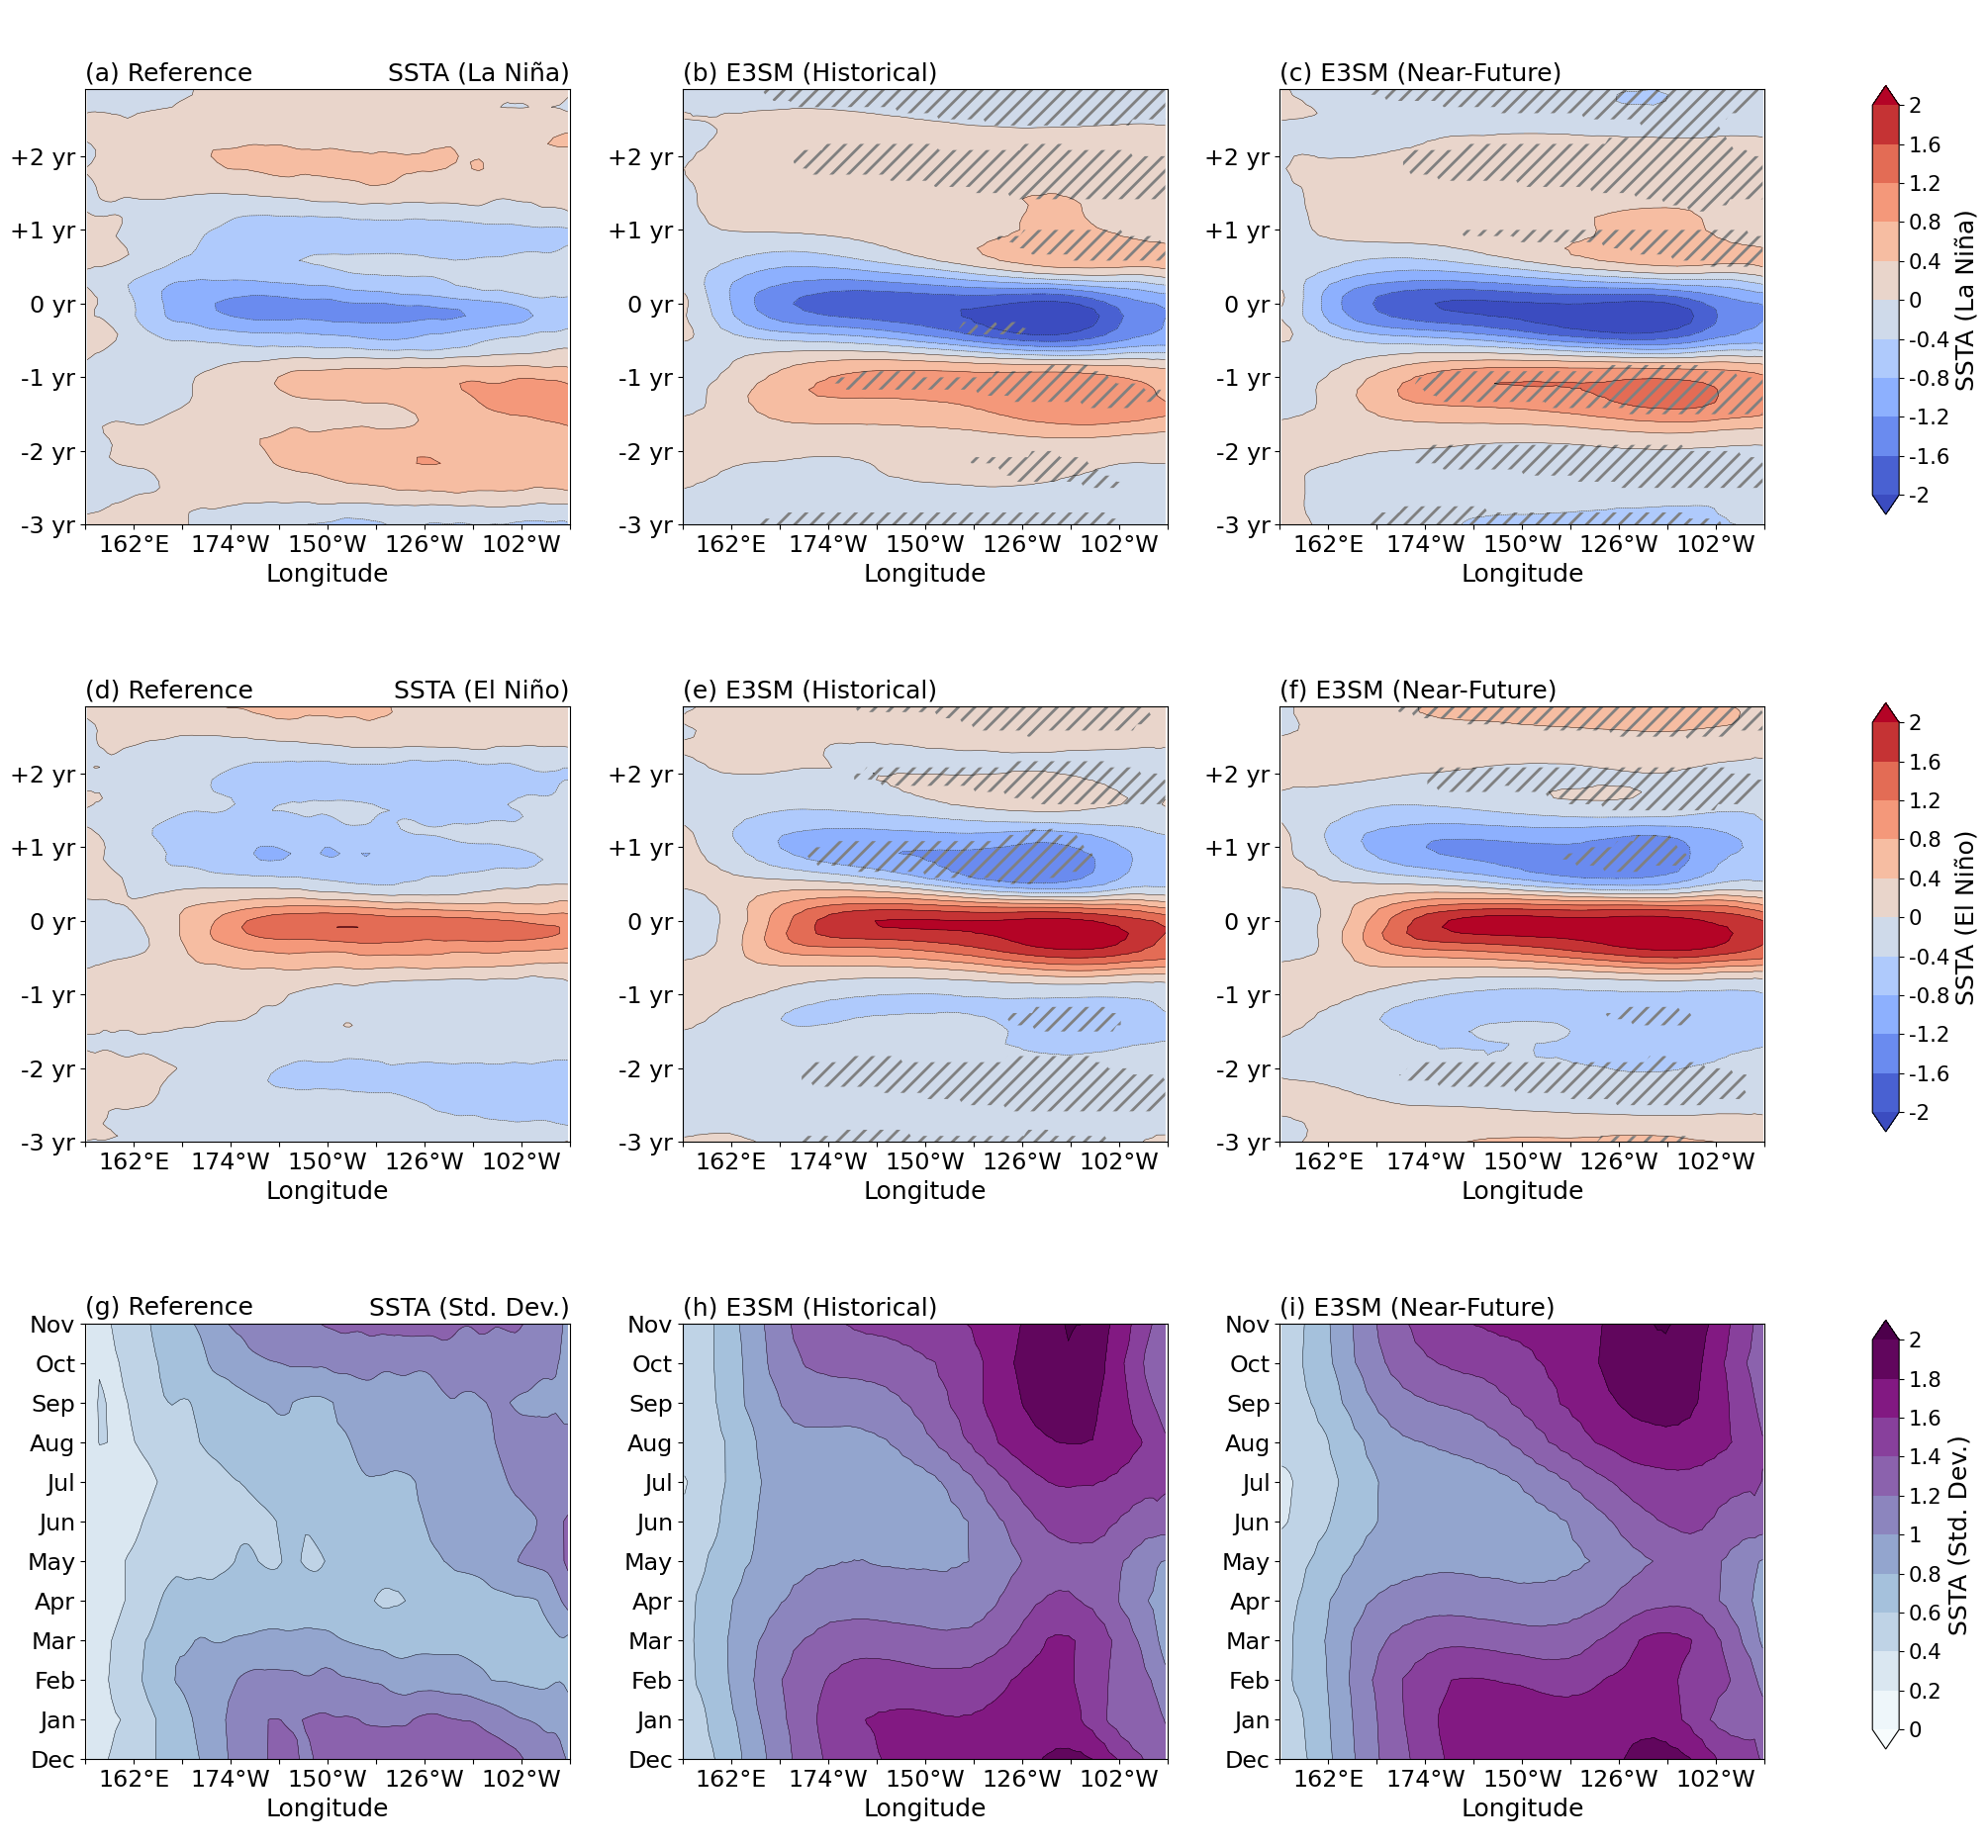

In [5]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    MODEL   = "v3.LR.historical"
    GROUP   = ["hist", "future"]
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]
    case_id = "v20251015"

    members = None
    verbose = False
    diag_print = True

    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=GROUP,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )

    target_metric_dict = {
        "enso_sst_ts_rmse": {
            "vars": ["Nina_sst_hov", "Nino_sst_hov"],
            "vmap": {
                "Nina_sst_hov": "SSTA (La Niña)",
                "Nino_sst_hov": "SSTA (El Niño)",
            },
            "obs": {"hist": "ERA-Interim", "future": "ERA-Interim2"},
            "group": "ENSO_perf",
            "rtol": 1e2,
            "cmap": "coolwarm",
            "levels": np.linspace(-2, 2, 11),
            "roll_idx": 0,
        },
        "enso_seasonality": {
            "vars": ["sstStd_hov"],
            "vmap": {
                "sstStd_hov": "SSTA (Std. Dev.)",
            },
            "obs": {"hist": "ERA-Interim", "future": "ERA-Interim2"},
            "group": "ENSO_perf",
            "rtol": 1e-1,
            "cmap": "BuPu",
            "levels": np.linspace(0, 2, 11),
            "roll_idx": 1,
        },
    }

    pool_members_to_samples = False

    # ------------------------------------------------------------
    # Collect ALL rows (3 variables total) across BOTH metrics
    # ------------------------------------------------------------
    all_plotters   = []
    all_var_labels = []
    all_cmaps      = []
    all_levels     = []
    all_roll_idx   = []

    # fixed plot meta
    plot_dict = {
        "reference": {"label": "Reference"},
        "hist":      {"label": "E3SM (Historical)"},
        "future":    {"label": "E3SM (Near-Future)"},
    }

    overlay_spread  = True
    spread_quantile = 0.75
    spread_level    = None
    fig_aspect      = 0.9
    figure_format   = "pdf"
    figure_dpi      = 300
    figsize         = (24,24)   # taller for 3 rows
    fontz           = 18
    cb_shrink       = 0.85
    obs_key         = "reference"
    lat_name        = "months"
    lon_name        = "longitude"
    hspace          = 0.04
    wspace          = 0.30

    # ---- loop over metrics and vars, but DO NOT plot yet ----
    for target_metric, meta in target_metric_dict.items():
        target_var_list = meta["vars"]
        target_obs_dict = meta["obs"]
        target_group    = meta["group"]
        target_rtol     = meta["rtol"]

        print("Available ENSO groups:", reader.available_groups())
        print(f"Variables in {target_group}:", reader.available_vars(target_group))

        if target_group not in reader.available_groups():
            raise ValueError(f"Unknown target_group: {target_group}")
        if target_metric not in reader.available_vars(target_group):
            raise ValueError(f"Unknown target_metric '{target_metric}' for '{target_group}'")

        for target_var in target_var_list:
            print(f"\n>>> Loading target_metric={target_metric} target_var={target_var}")

            dm, do = reader.load_metric_data(
                enso_group=target_group,
                var_name=target_metric,
                nc_var=target_var,
                ref_dict=target_obs_dict,
                case_id=case_id,
            )

            ref = reader.validate_constant_observation(
                do, ref_group="hist", ref_member="00", sample_dim=None,
                use_allclose=True, rtol=target_rtol, atol=0.0,
                pool_ensemble=pool_members_to_samples,
            )

            data_dict = {obs_key: ref}
            for group, member_dict in dm.items():
                pooled = reader.combine_members_to_array(member_dict, sample_dim=None)
                data_dict[group] = pooled

            if diag_print:
                print(f"\nVariable: {target_var}")
                for group, da in data_dict.items():
                    print(f"  Group: {group}")
                    print(f"type={type(da).__name__} | shape={getattr(da,'shape',None)} | dims={getattr(da,'dims',None)}")

            mp = ENSOPatternMapPlotter(
                data_dict=data_dict,
                fig_dir=FIG_DIR,
                plot_dict=plot_dict,
                group_order=GROUP,
                obs_key=obs_key,
                lat_name=lat_name,
                lon_name=lon_name,
            )

            all_plotters.append(mp)
            all_var_labels.append(meta["vmap"][target_var])
            all_cmaps.append(meta["cmap"])
            all_levels.append(meta["levels"])
            all_roll_idx.append(meta["roll_idx"])

            # optional spread min/max print
            for g in GROUP:
                if g in mp.spread_maps:
                    s = mp.spread_maps[g]
                    print(target_var, g, "min spread =", float(s.min()), "max spread =", float(s.max()))

    # ------------------------------------------------------------
    # ONE combined figure: 3 rows × 3 cols
    # ------------------------------------------------------------
    figure_name = f"enso_nino_nina_stdsst_hist_future_hov_erai_v0.{figure_format}"

    # Use the first plotter to call the shared plotting routine
    all_plotters[0].plot_multi_maps(
        plotters=all_plotters,
        var_labels=all_var_labels,
        filename=figure_name,
        figsize=figsize,
        fontz=fontz,
        cmaps=all_cmaps,
        mlevels_list=all_levels,
        cb_labels=all_var_labels,     # one colorbar per row
        roll_idx_list=all_roll_idx,
        overlay_spread=overlay_spread,
        spread_quantile=spread_quantile,
        spread_level=spread_level,
        wspace=wspace,
        hspace=hspace,
        fig_format=figure_format,
        fig_aspect=fig_aspect,
        fig_dpi=figure_dpi,
        cb_shrink=cb_shrink,
    )

Available ENSO groups: ['ENSO_perf', 'ENSO_proc', 'ENSO_tel']
Variables in ENSO_perf: ['pr_lat_rmse', 'pr_lon_rmse', 'sst_lon_rmse', 'taux_lon_rmse', 'enso_amplitude', 'enso_duration', 'enso_seasonality', 'enso_sst_diversity_mode1', 'enso_sst_diversity_mode2', 'enso_sst_lon_rmse', 'enso_sst_skewness', 'enso_sst_ts_rmse', 'seasonal_pr_lat_rmse', 'seasonal_pr_lon_rmse', 'seasonal_sst_lon_rmse', 'seasonal_taux_lon_rmse']

>>> Loading target_metric=enso_sst_ts_rmse target_var=Nina_sst_hov
processing period: hist
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260216*_EnsoSstTsRmse.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260216*_EnsoSstTsRmse.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0101/pcmdi_diags/mo

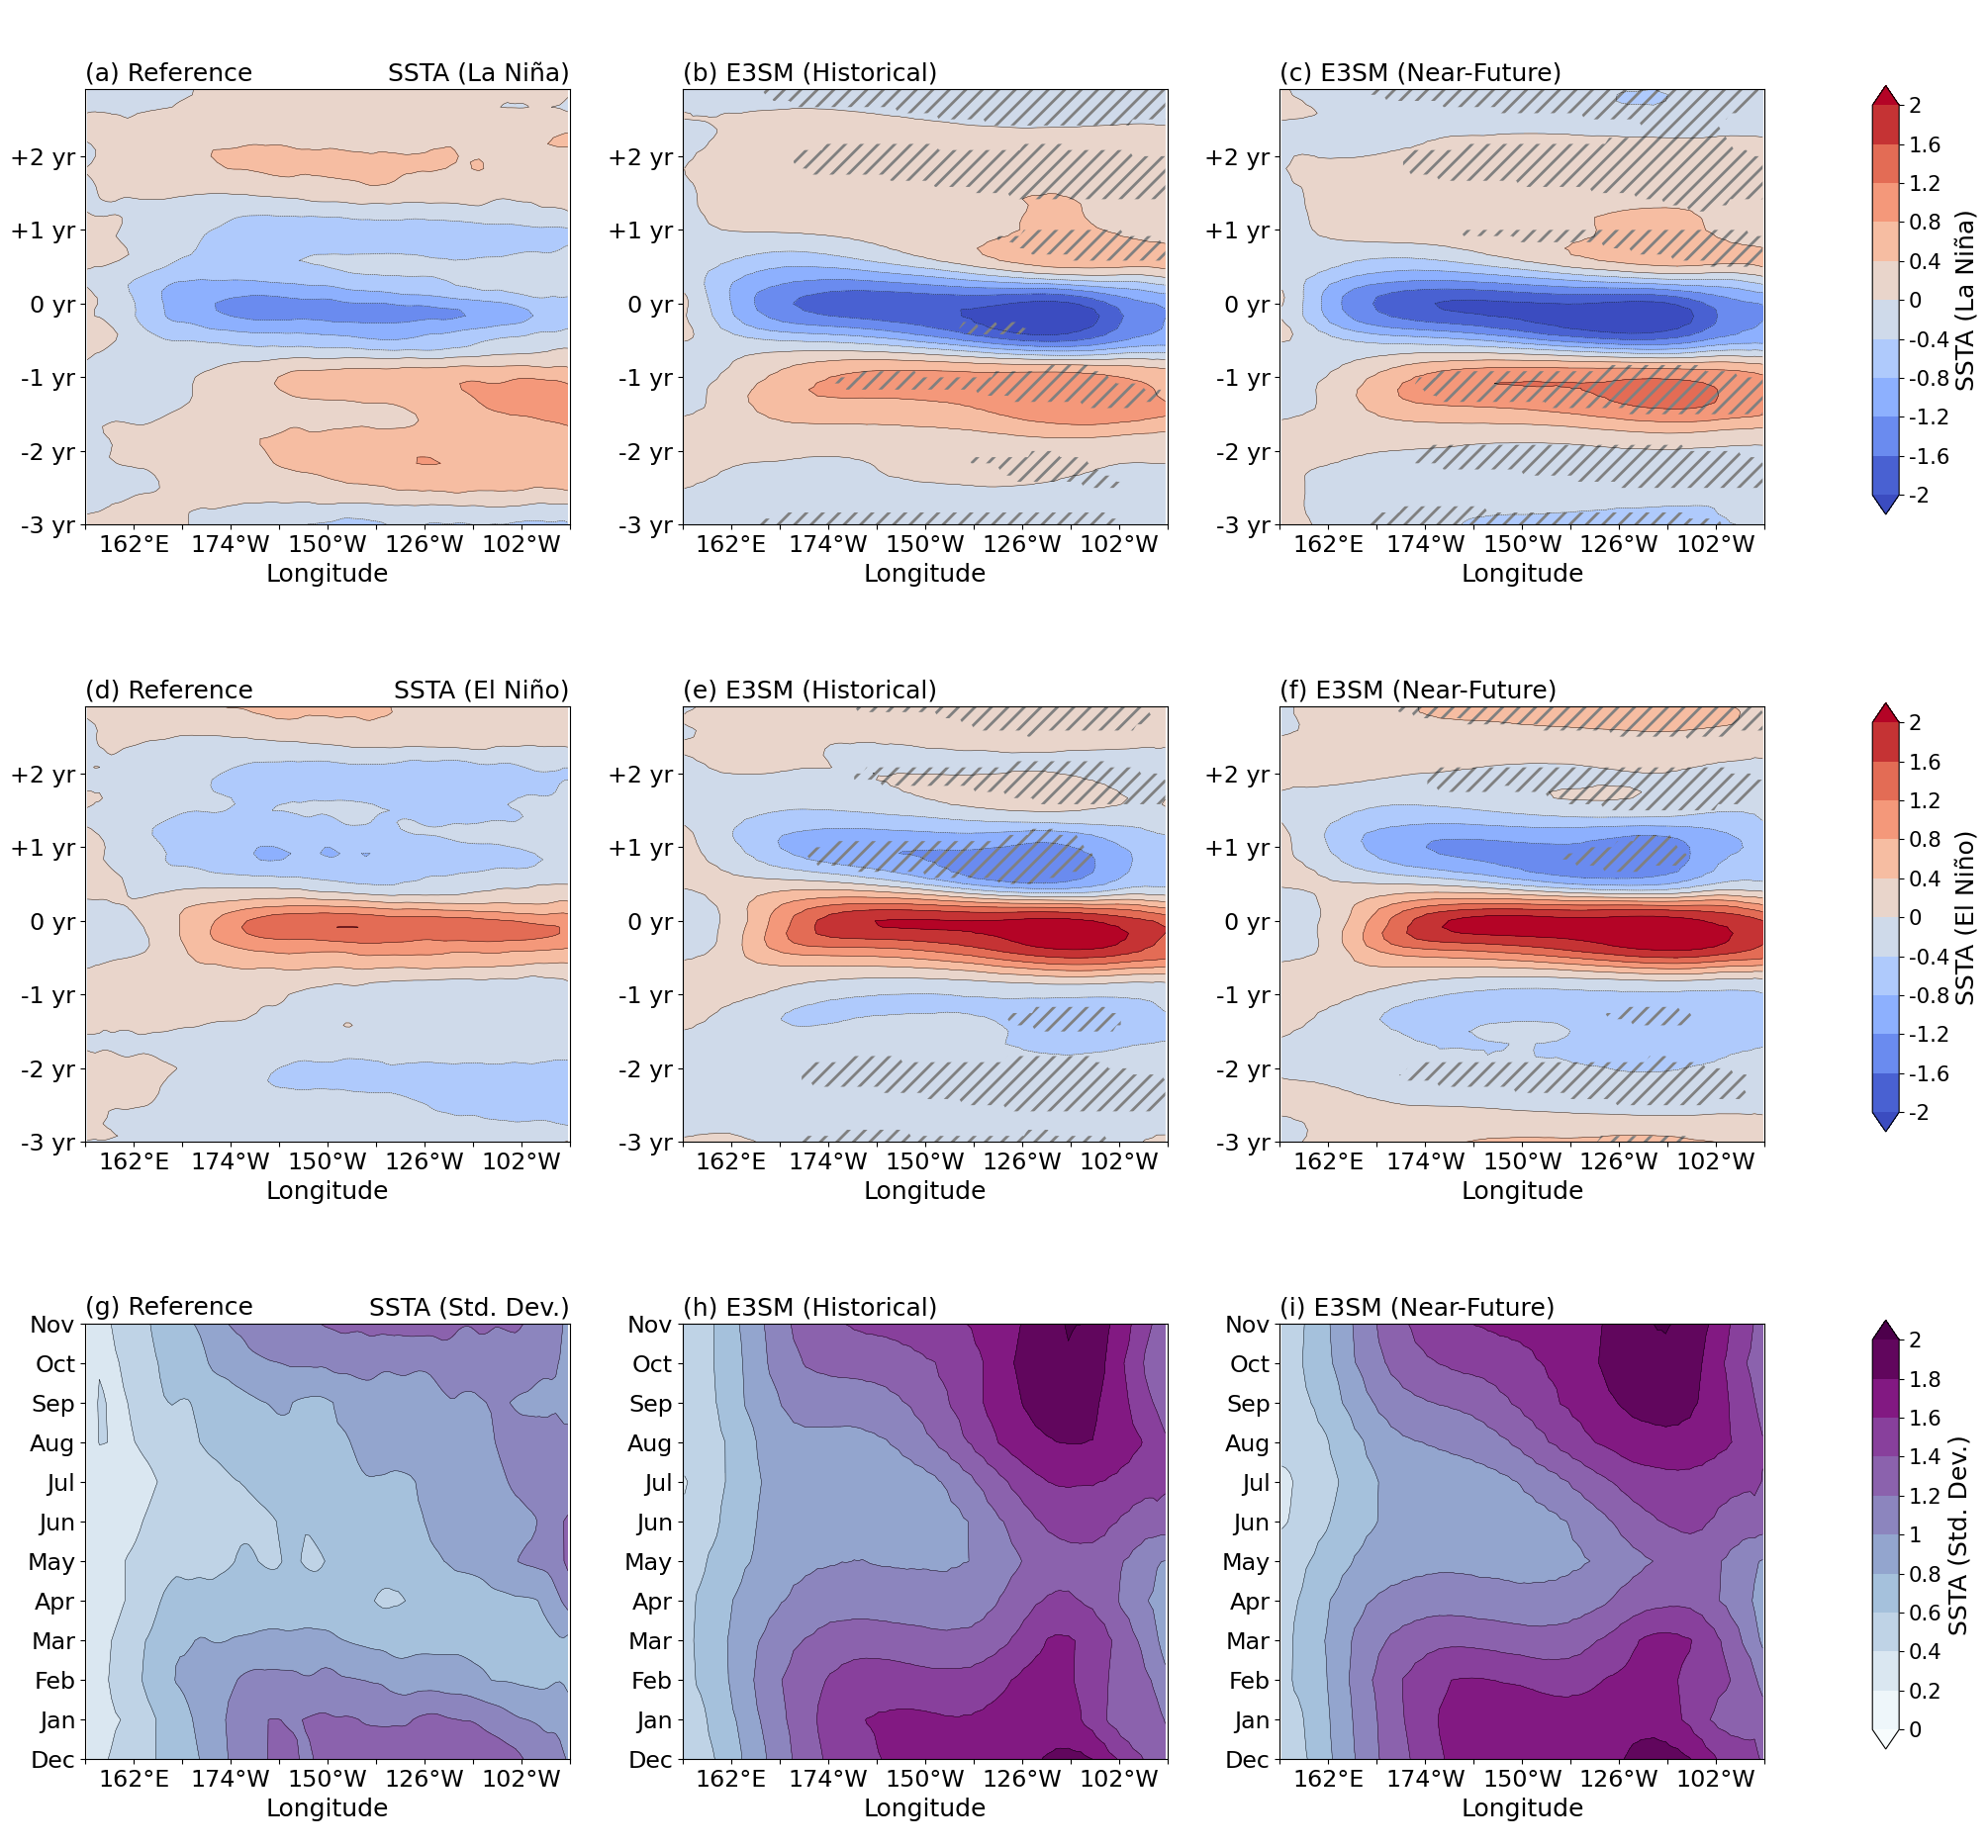

In [7]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    MODEL   = "v3.LR.historical"
    GROUP   = ["hist", "future"]
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]
    case_id = "v20260216"

    members = None
    verbose = False
    diag_print = True

    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=GROUP,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )

    target_metric_dict = {
        "enso_sst_ts_rmse": {
            "vars": ["Nina_sst_hov", "Nino_sst_hov"],
            "vmap": {
                "Nina_sst_hov": "SSTA (La Niña)",
                "Nino_sst_hov": "SSTA (El Niño)",
            },
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},
            "group": "ENSO_perf",
            "rtol": 1e2,
            "cmap": "coolwarm",
            "levels": np.linspace(-2, 2, 11),
            "roll_idx": 0,
        },
        "enso_seasonality": {
            "vars": ["sstStd_hov"],
            "vmap": {
                "sstStd_hov": "SSTA (Std. Dev.)",
            },
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},
            "group": "ENSO_perf",
            "rtol": 1e-1,
            "cmap": "BuPu",
            "levels": np.linspace(0, 2, 11),
            "roll_idx": 1,
        },
    }

    pool_members_to_samples = False

    # ------------------------------------------------------------
    # Collect ALL rows (3 variables total) across BOTH metrics
    # ------------------------------------------------------------
    all_plotters   = []
    all_var_labels = []
    all_cmaps      = []
    all_levels     = []
    all_roll_idx   = []

    # fixed plot meta
    plot_dict = {
        "reference": {"label": "Reference"},
        "hist":      {"label": "E3SM (Historical)"},
        "future":    {"label": "E3SM (Near-Future)"},
    }

    overlay_spread  = True
    spread_quantile = 0.75
    spread_level    = None
    fig_aspect      = 0.9
    figure_format   = "pdf"
    figure_dpi      = 300
    figsize         = (24,24)   # taller for 3 rows
    fontz           = 18
    cb_shrink       = 0.85
    obs_key         = "reference"
    lat_name        = "months"
    lon_name        = "longitude"
    hspace          = 0.04
    wspace          = 0.30

    # ---- loop over metrics and vars, but DO NOT plot yet ----
    for target_metric, meta in target_metric_dict.items():
        target_var_list = meta["vars"]
        target_obs_dict = meta["obs"]
        target_group    = meta["group"]
        target_rtol     = meta["rtol"]

        print("Available ENSO groups:", reader.available_groups())
        print(f"Variables in {target_group}:", reader.available_vars(target_group))

        if target_group not in reader.available_groups():
            raise ValueError(f"Unknown target_group: {target_group}")
        if target_metric not in reader.available_vars(target_group):
            raise ValueError(f"Unknown target_metric '{target_metric}' for '{target_group}'")

        for target_var in target_var_list:
            print(f"\n>>> Loading target_metric={target_metric} target_var={target_var}")

            dm, do = reader.load_metric_data(
                enso_group=target_group,
                var_name=target_metric,
                nc_var=target_var,
                ref_dict=target_obs_dict,
                case_id=case_id,
            )

            ref = reader.validate_constant_observation(
                do, ref_group="hist", ref_member="00", sample_dim=None,
                use_allclose=True, rtol=target_rtol, atol=0.0,
                pool_ensemble=pool_members_to_samples,
            )

            data_dict = {obs_key: ref}
            for group, member_dict in dm.items():
                pooled = reader.combine_members_to_array(member_dict, sample_dim=None)
                data_dict[group] = pooled

            if diag_print:
                print(f"\nVariable: {target_var}")
                for group, da in data_dict.items():
                    print(f"  Group: {group}")
                    print(f"type={type(da).__name__} | shape={getattr(da,'shape',None)} | dims={getattr(da,'dims',None)}")

            mp = ENSOPatternMapPlotter(
                data_dict=data_dict,
                fig_dir=FIG_DIR,
                plot_dict=plot_dict,
                group_order=GROUP,
                obs_key=obs_key,
                lat_name=lat_name,
                lon_name=lon_name,
            )

            all_plotters.append(mp)
            all_var_labels.append(meta["vmap"][target_var])
            all_cmaps.append(meta["cmap"])
            all_levels.append(meta["levels"])
            all_roll_idx.append(meta["roll_idx"])

            # optional spread min/max print
            for g in GROUP:
                if g in mp.spread_maps:
                    s = mp.spread_maps[g]
                    print(target_var, g, "min spread =", float(s.min()), "max spread =", float(s.max()))

    # ------------------------------------------------------------
    # ONE combined figure: 3 rows × 3 cols
    # ------------------------------------------------------------
    figure_name = f"enso_nino_nina_stdsst_hist_future_hov_erai.{figure_format}"

    # Use the first plotter to call the shared plotting routine
    all_plotters[0].plot_multi_maps(
        plotters=all_plotters,
        var_labels=all_var_labels,
        filename=figure_name,
        figsize=figsize,
        fontz=fontz,
        cmaps=all_cmaps,
        mlevels_list=all_levels,
        cb_labels=all_var_labels,     # one colorbar per row
        roll_idx_list=all_roll_idx,
        overlay_spread=overlay_spread,
        spread_quantile=spread_quantile,
        spread_level=spread_level,
        wspace=wspace,
        hspace=hspace,
        fig_format=figure_format,
        fig_aspect=fig_aspect,
        fig_dpi=figure_dpi,
        cb_shrink=cb_shrink,
    )

Available ENSO groups: ['ENSO_perf', 'ENSO_proc', 'ENSO_tel']
Variables in ENSO_perf: ['pr_lat_rmse', 'pr_lon_rmse', 'sst_lon_rmse', 'taux_lon_rmse', 'enso_amplitude', 'enso_duration', 'enso_seasonality', 'enso_sst_diversity_mode1', 'enso_sst_diversity_mode2', 'enso_sst_lon_rmse', 'enso_sst_skewness', 'enso_sst_ts_rmse', 'seasonal_pr_lat_rmse', 'seasonal_pr_lon_rmse', 'seasonal_sst_lon_rmse', 'seasonal_taux_lon_rmse']

>>> Loading target_metric=enso_sst_ts_rmse target_var=Nina_sst_hov
processing period: hist
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260212*_EnsoSstTsRmse.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260212*_EnsoSstTsRmse.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0101/pcmdi_diags/mo

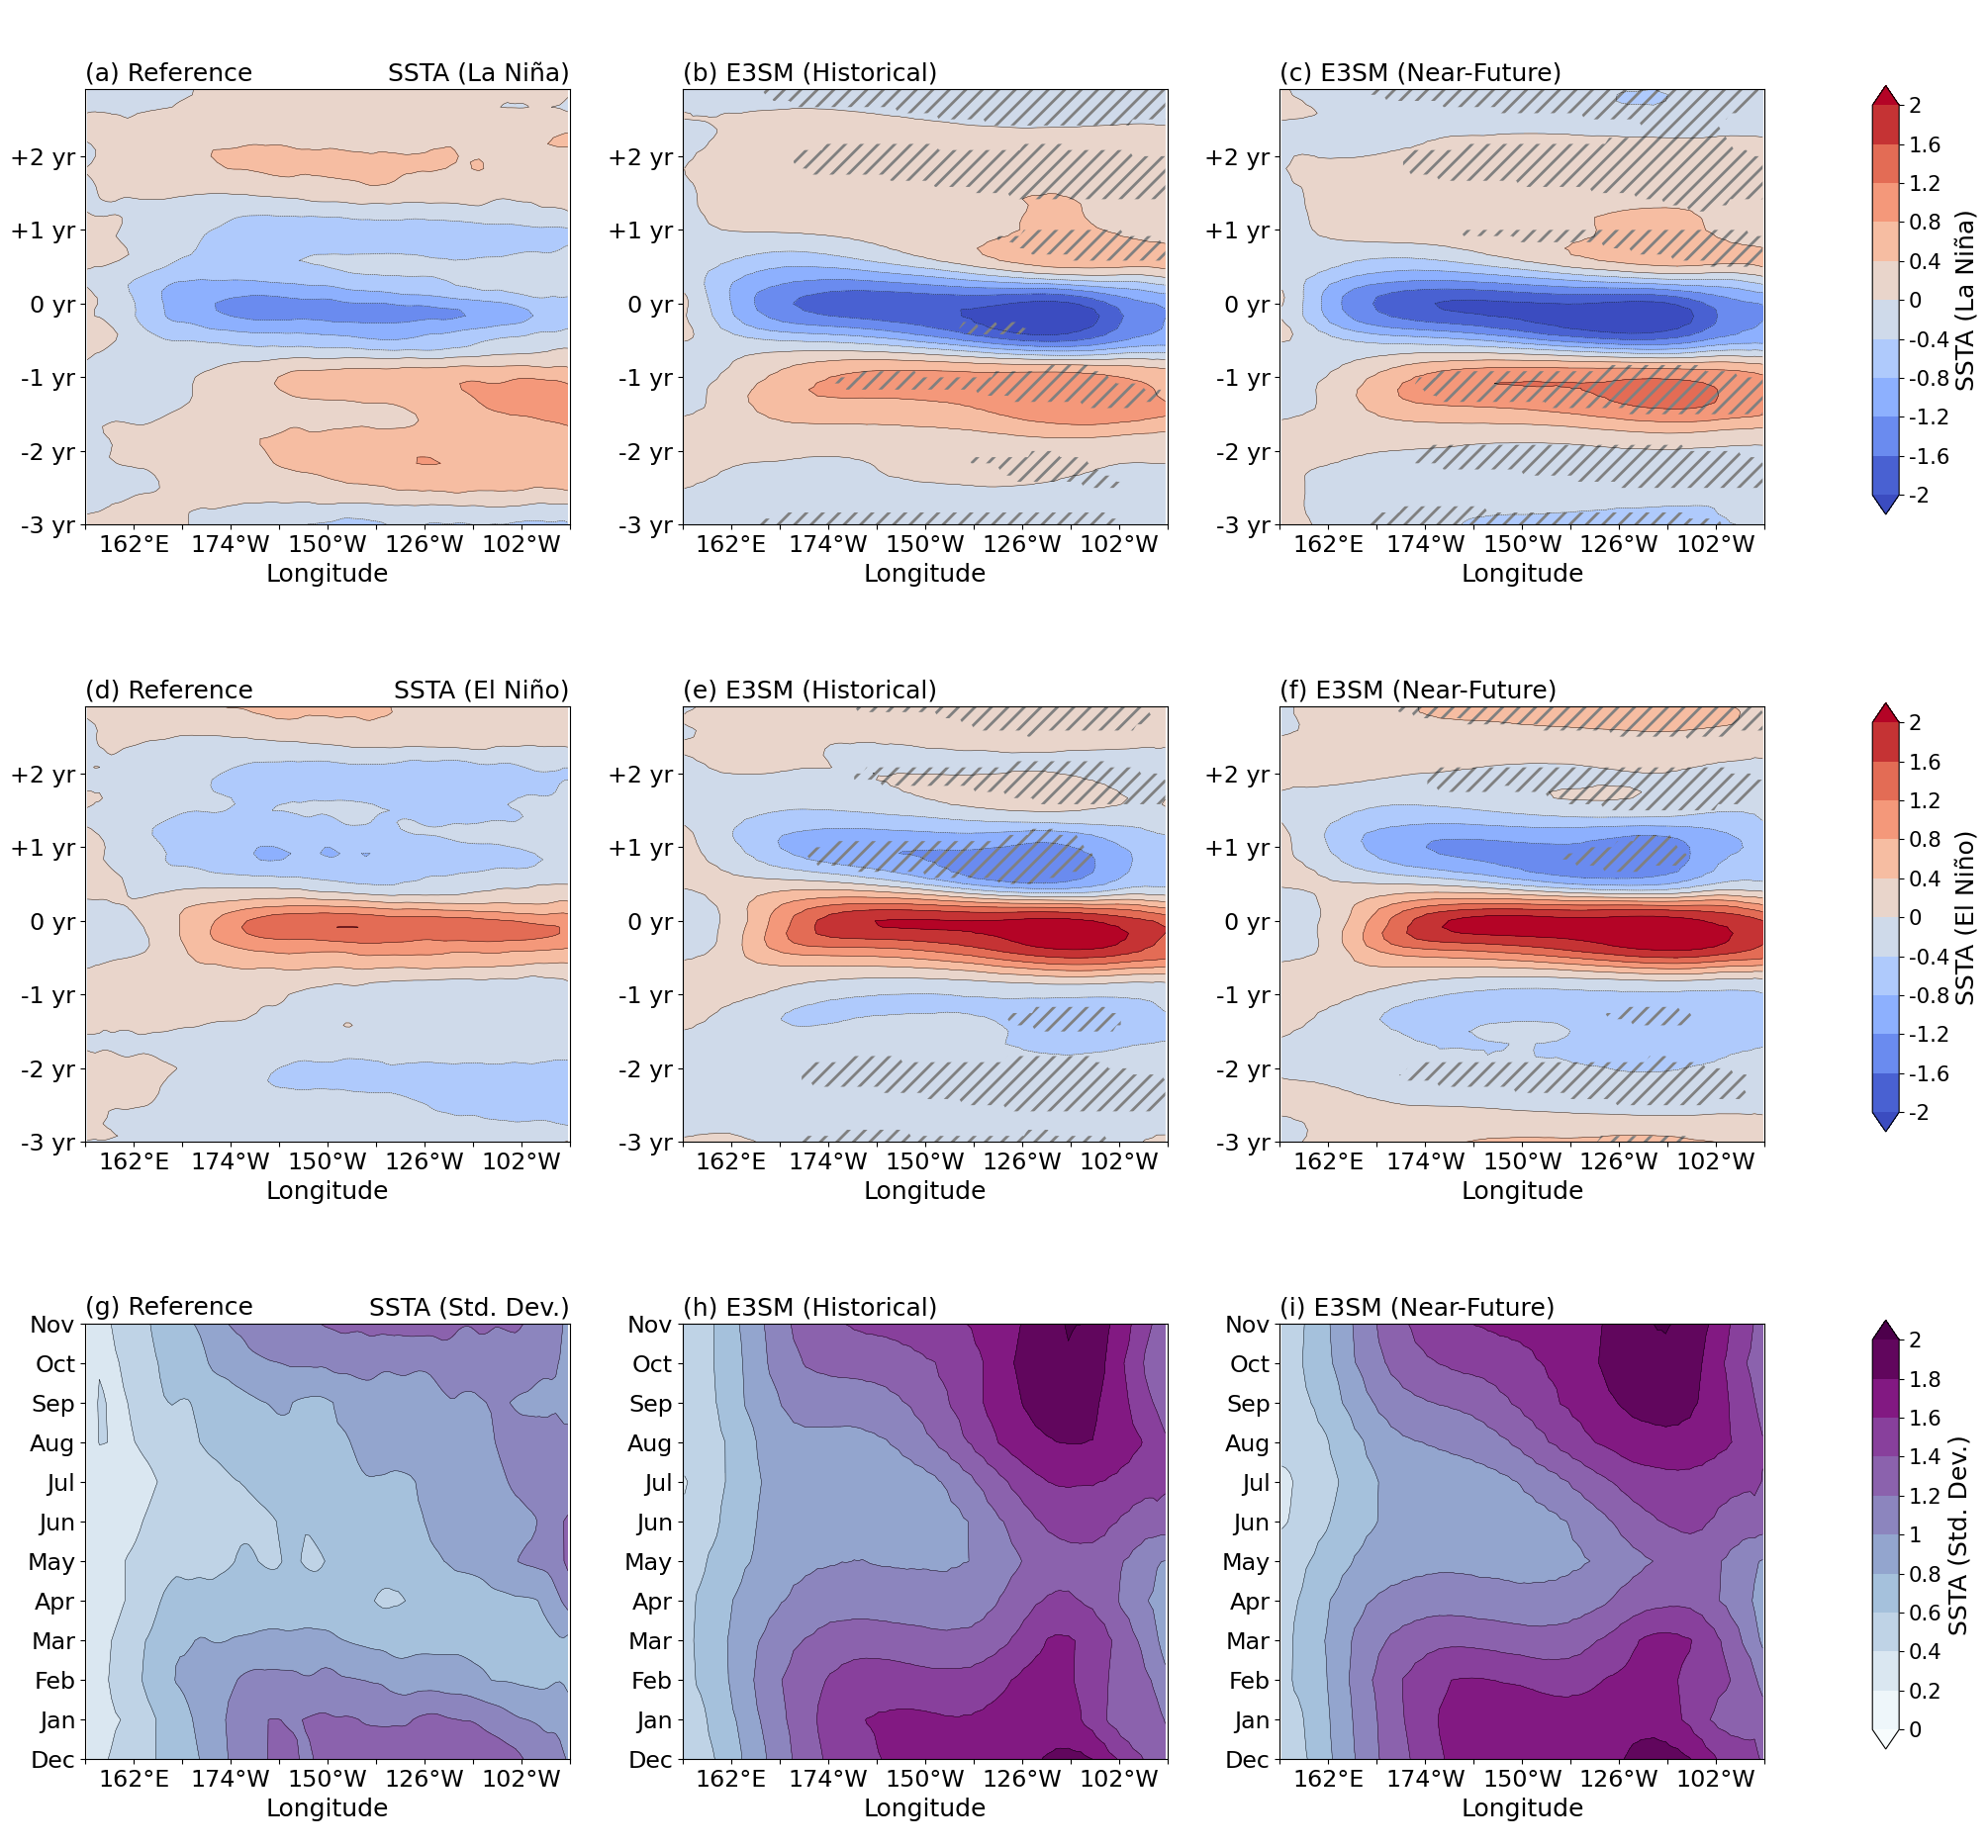

In [8]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    MODEL   = "v3.LR.historical"
    GROUP   = ["hist", "future"]
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]
    case_id = "v20260212"

    members = None
    verbose = False
    diag_print = True

    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=GROUP,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )

    target_metric_dict = {
        "enso_sst_ts_rmse": {
            "vars": ["Nina_sst_hov", "Nino_sst_hov"],
            "vmap": {
                "Nina_sst_hov": "SSTA (La Niña)",
                "Nino_sst_hov": "SSTA (El Niño)",
            },
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},
            "group": "ENSO_perf",
            "rtol": 1e2,
            "cmap": "coolwarm",
            "levels": np.linspace(-2, 2, 11),
            "roll_idx": 0,
        },
        "enso_seasonality": {
            "vars": ["sstStd_hov"],
            "vmap": {
                "sstStd_hov": "SSTA (Std. Dev.)",
            },
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},
            "group": "ENSO_perf",
            "rtol": 1e-1,
            "cmap": "BuPu",
            "levels": np.linspace(0, 2, 11),
            "roll_idx": 1,
        },
    }

    pool_members_to_samples = False

    # ------------------------------------------------------------
    # Collect ALL rows (3 variables total) across BOTH metrics
    # ------------------------------------------------------------
    all_plotters   = []
    all_var_labels = []
    all_cmaps      = []
    all_levels     = []
    all_roll_idx   = []

    # fixed plot meta
    plot_dict = {
        "reference": {"label": "Reference"},
        "hist":      {"label": "E3SM (Historical)"},
        "future":    {"label": "E3SM (Near-Future)"},
    }

    overlay_spread  = True
    spread_quantile = 0.75
    spread_level    = None
    fig_aspect      = 0.9
    figure_format   = "pdf"
    figure_dpi      = 300
    figsize         = (24,24)   # taller for 3 rows
    fontz           = 18
    cb_shrink       = 0.85
    obs_key         = "reference"
    lat_name        = "months"
    lon_name        = "longitude"
    hspace          = 0.04
    wspace          = 0.30

    # ---- loop over metrics and vars, but DO NOT plot yet ----
    for target_metric, meta in target_metric_dict.items():
        target_var_list = meta["vars"]
        target_obs_dict = meta["obs"]
        target_group    = meta["group"]
        target_rtol     = meta["rtol"]

        print("Available ENSO groups:", reader.available_groups())
        print(f"Variables in {target_group}:", reader.available_vars(target_group))

        if target_group not in reader.available_groups():
            raise ValueError(f"Unknown target_group: {target_group}")
        if target_metric not in reader.available_vars(target_group):
            raise ValueError(f"Unknown target_metric '{target_metric}' for '{target_group}'")

        for target_var in target_var_list:
            print(f"\n>>> Loading target_metric={target_metric} target_var={target_var}")

            dm, do = reader.load_metric_data(
                enso_group=target_group,
                var_name=target_metric,
                nc_var=target_var,
                ref_dict=target_obs_dict,
                case_id=case_id,
            )

            ref = reader.validate_constant_observation(
                do, ref_group="hist", ref_member="00", sample_dim=None,
                use_allclose=True, rtol=target_rtol, atol=0.0,
                pool_ensemble=pool_members_to_samples,
            )

            data_dict = {obs_key: ref}
            for group, member_dict in dm.items():
                pooled = reader.combine_members_to_array(member_dict, sample_dim=None)
                data_dict[group] = pooled

            if diag_print:
                print(f"\nVariable: {target_var}")
                for group, da in data_dict.items():
                    print(f"  Group: {group}")
                    print(f"type={type(da).__name__} | shape={getattr(da,'shape',None)} | dims={getattr(da,'dims',None)}")

            mp = ENSOPatternMapPlotter(
                data_dict=data_dict,
                fig_dir=FIG_DIR,
                plot_dict=plot_dict,
                group_order=GROUP,
                obs_key=obs_key,
                lat_name=lat_name,
                lon_name=lon_name,
            )

            all_plotters.append(mp)
            all_var_labels.append(meta["vmap"][target_var])
            all_cmaps.append(meta["cmap"])
            all_levels.append(meta["levels"])
            all_roll_idx.append(meta["roll_idx"])

            # optional spread min/max print
            for g in GROUP:
                if g in mp.spread_maps:
                    s = mp.spread_maps[g]
                    print(target_var, g, "min spread =", float(s.min()), "max spread =", float(s.max()))

    # ------------------------------------------------------------
    # ONE combined figure: 3 rows × 3 cols
    # ------------------------------------------------------------
    figure_name = f"enso_nino_nina_stdsst_hist_future_hov.{figure_format}"

    # Use the first plotter to call the shared plotting routine
    all_plotters[0].plot_multi_maps(
        plotters=all_plotters,
        var_labels=all_var_labels,
        filename=figure_name,
        figsize=figsize,
        fontz=fontz,
        cmaps=all_cmaps,
        mlevels_list=all_levels,
        cb_labels=all_var_labels,     # one colorbar per row
        roll_idx_list=all_roll_idx,
        overlay_spread=overlay_spread,
        spread_quantile=spread_quantile,
        spread_level=spread_level,
        wspace=wspace,
        hspace=hspace,
        fig_format=figure_format,
        fig_aspect=fig_aspect,
        fig_dpi=figure_dpi,
        cb_shrink=cb_shrink,
    )